# Guidance walkthrough: cost functions, guided sampling, and animation

Demonstrates the guidance machinery in `src/transferable_samplers/guidance/`:

1. **Baseline: unguided sampling** — what the model produces with no cost
   function, for comparison against every guided result below.
2. **Cost-shaping primitives** (`guidance/costs.py`) — building blocks that
   turn an observable into a per-sample scalar cost.
3. **Differentiable observables** (`guidance/observables.py`) — phi/psi
   dihedral angles from atom positions.
4. **Composing terminal cost functions** — `pos_phi`, `phi_target`,
   `phi_psi_target`, and `smiley` objectives, including chirality correction.
5. **Guided Euler sampling** (`guidance/euler_density_integrator.py`) —
   drawing guided samples and plotting the resulting Ramachandran
   distribution.
6. **Animating a guided trajectory as a GIF**.
7. **Guided sampling with exact density tracking** — runtime and
   orientation-flip reporting on a small batch.

Sample/step counts are kept small so the notebook runs quickly. Raise
`NUM_SAMPLES`, `EULER_STEPS`, and `NUM_FRAMES` for higher-quality figures.

## Setup

Loads the trained ECNF++ model and the alanine-dipeptide (`Ace-A-Nme`)
evaluation context, and looks up the phi/psi dihedral atom indices.

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import hydra
import matplotlib.pyplot as plt
import numpy as np
import torch
from dotenv import load_dotenv
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

from transferable_samplers.evaluation.metrics.wasserstein_distances import energy_wasserstein
from transferable_samplers.evaluation.plots.plot_ramachandran import plot_ramachandran
from transferable_samplers.guidance.costs import (
    box_quadratic_penalty,
    one_sided_quadratic_penalty,
    quadratic_target_penalty,
    repel_within_radius_penalty,
    torus_distance,
    within_radius_penalty,
)
from transferable_samplers.guidance.euler_density_integrator import generate_proposal_guided_euler
from transferable_samplers.guidance.observables import dihedrals, get_dihedral_atom_indices
from transferable_samplers.utils.chirality import ChiralitySignChecker
from transferable_samplers.utils.init_resume_utils import resolve_init
from transferable_samplers.utils.standardization import destandardize_coords
from tqdm import tqdm


def find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists() and (p / "configs").is_dir():
            return p
    raise RuntimeError(
        "Could not locate the repo root from the notebook's cwd "
        f"({start}). Launch Jupyter from inside the repo, or set REPO_ROOT by hand."
    )


REPO_ROOT = find_repo_root(Path.cwd())
CONFIG_DIR = str(REPO_ROOT / "configs")
OUT_DIR = REPO_ROOT / "tests" / "guidance" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO_ROOT / "tests" / "guidance" / "visualization"))

load_dotenv(REPO_ROOT / ".env", override=True)  # reads SCRATCH_DIR, etc.

print(f"REPO_ROOT={REPO_ROOT}")

REPO_ROOT=/workspace/guided_BG


In [2]:
SEQUENCE = "Ace-A-Nme"


def load_model_and_data():
    GlobalHydra.instance().clear()
    with initialize_config_dir(version_base="1.3", config_dir=CONFIG_DIR):
        cfg = compose(
            config_name="eval",
            overrides=["experiment=single_system/eval/ecnf++_Ace-A-Nme_snis"],
        )

    datamodule = hydra.utils.instantiate(cfg.data)
    datamodule.prepare_data()  # no-op if already downloaded

    model = hydra.utils.instantiate(cfg.model)
    state_dict = resolve_init(
        init_ckpt_path=cfg.get("ckpt_path"),
        init_hf_state_dict_path=cfg.get("hf_state_dict_path"),
        scratch_dir=cfg.paths.scratch_dir,
    )
    model.load_state_dict(state_dict)
    return model, datamodule, cfg.data.num_atoms


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

model, datamodule, num_atoms = load_model_and_data()
model = model.to(device).eval()

eval_ctx = datamodule.prepare_eval(sequence=SEQUENCE, stage="test")
phi_idx = get_dihedral_atom_indices(eval_ctx.topology, kind="phi")
psi_idx = get_dihedral_atom_indices(eval_ctx.topology, kind="psi")
# precomputed once -- rebuilding this per guidance step would be too slow
chirality_checker = ChiralitySignChecker(eval_ctx.topology, eval_ctx.true_data.samples[:1])

print(f"num_atoms={num_atoms}, phi dihedrals={len(phi_idx)}, psi dihedrals={len(psi_idx)}")

device: cuda


/workspace/guided_BG/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


Model weights downloaded successfully to /workspace/guided_BG/scratch/transferable-samplers/model-weights
num_atoms=22, phi dihedrals=1, psi dihedrals=1


In [3]:
# Batch size caps for generate_proposal_guided_euler: exact density tracking
# needs a full Jacobian per step, so it only stays cheap at a small batch size.
BATCH_SIZE_NO_DENSITY = 128
BATCH_SIZE_DENSITY = 16


def sample_guided_batched(num_samples: int, batch_size: int, terminal_cost, **kwargs):
    """Calls generate_proposal_guided_euler in batches of at most batch_size, concatenating results."""
    xs, neg_logqs, valids = [], [], []
    num_batches = (num_samples + batch_size - 1) // batch_size
    for i in tqdm(range(num_batches), desc="sampling batches"):
        n = min(batch_size, num_samples - i * batch_size)
        x, neg_logq, valid = generate_proposal_guided_euler(model, n, num_atoms, terminal_cost, **kwargs)
        xs.append(x.detach())
        if neg_logq is not None:
            neg_logqs.append(neg_logq.detach())
        if valid is not None:
            valids.append(valid.detach())
    x = torch.cat(xs, dim=0)
    neg_logq = torch.cat(neg_logqs, dim=0) if neg_logqs else None
    valid = torch.cat(valids, dim=0) if valids else None
    return x, neg_logq, valid

## 1. Baseline: unguided sampling

Setting the cost weight to zero (`alpha=0`, `n_inner=0` reduces the guided
integrator to plain Euler) shows what the model produces without any
steering, for comparison against every guided result below.

sampling batches: 100%|██████████| 79/79 [16:34<00:00, 12.59s/it]


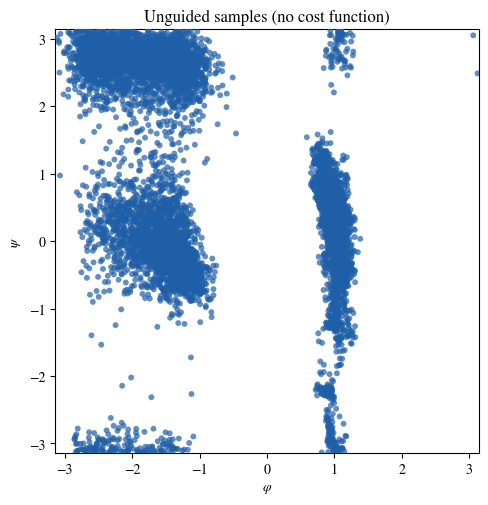

In [4]:
NUM_SAMPLES_UNGUIDED = 10000
EULER_STEPS = 250

torch.manual_seed(42)
x_unguided, _, _ = sample_guided_batched(
    NUM_SAMPLES_UNGUIDED, BATCH_SIZE_NO_DENSITY,
    lambda x1, t: torch.zeros(x1.shape[0], device=x1.device, dtype=x1.dtype),
    alpha=0.0, n_inner=0, n_steps=EULER_STEPS,
    device=device, track_density=False,
)
samples_unguided = x_unguided.cpu()

samples_unguided_physical = destandardize_coords(samples_unguided, eval_ctx.normalization_std)
flip_mask_unguided = chirality_checker.flip_mask(samples_unguided_physical)
samples_unguided_physical = samples_unguided_physical.clone()
samples_unguided_physical[flip_mask_unguided] *= -1

phi_unguided = dihedrals(samples_unguided_physical, phi_idx).squeeze(-1).numpy()
psi_unguided = dihedrals(samples_unguided_physical, psi_idx).squeeze(-1).numpy()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(phi_unguided, psi_unguided, s=18, c="#1f5fa8", alpha=0.7, edgecolors="none", zorder=5)
ax.set_xlim(-np.pi, np.pi); ax.set_ylim(-np.pi, np.pi); ax.set_aspect("equal")
ax.set_xlabel(r"$\varphi$"); ax.set_ylabel(r"$\psi$")
ax.set_title("Unguided samples (no cost function)")
plt.show()

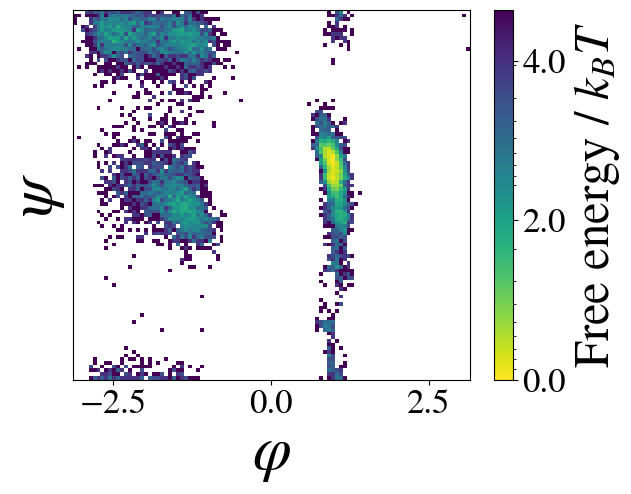

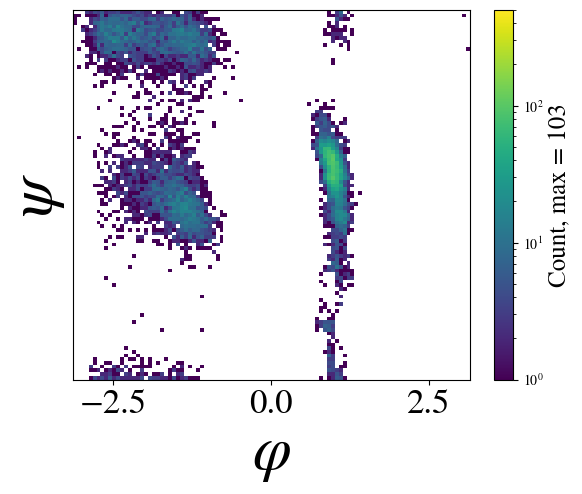

In [5]:
def log_image_fn(fig, name: str) -> None:
    path = OUT_DIR / f"{name.replace('/', '_')}.png"
    fig.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_ramachandran(
    log_image_fn, samples_unguided_physical, eval_ctx.topology,
    prefix="notebook_unguided",
)

In [6]:
from gif_guided_trajectory import make_guided_trajectory_gif

NUM_GIF_SAMPLES = 40
NUM_FRAMES = 60

GIF_PATH_UNGUIDED = make_guided_trajectory_gif(
    model, num_atoms, phi_idx, psi_idx, chirality_checker,
    cost_fn=lambda x1, t: torch.zeros(x1.shape[0], device=x1.device, dtype=x1.dtype),
    gif_path=OUT_DIR / "notebook_unguided_trajectory.gif",
    num_samples=NUM_GIF_SAMPLES,
    euler_steps=EULER_STEPS,
    num_frames=NUM_FRAMES,
    alpha=0.0,
    n_inner=0,
    seed=0,
    device=device,
    point_color="#1f5fa8",
)
print(f"saved {GIF_PATH_UNGUIDED}")

saved /workspace/guided_BG/tests/guidance/out/notebook_unguided_trajectory.gif


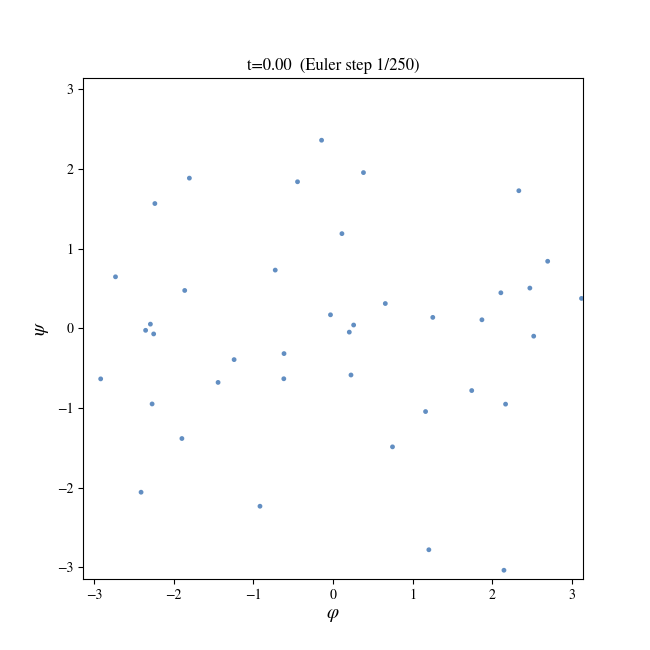

In [7]:
from IPython.display import Image

Image(filename=str(GIF_PATH_UNGUIDED))

## 2. Cost-shaping primitives

Each function in `guidance/costs.py` turns a scalar (or batched) observable
value into a non-negative cost.

- `one_sided_quadratic_penalty` — zero on one side of a threshold, quadratic
  on the other (e.g. "phi should be positive").
- `box_quadratic_penalty` — zero inside `[low, high]`, quadratic outside
  (degenerates to a single-point target when `low == high`).
- `torus_distance` — Euclidean distance in (phi, psi) space with each axis
  wrapped periodically on `[-pi, pi]`.
- `quadratic_target_penalty` — a quadratic bowl on top of a `torus_distance`.
- `within_radius_penalty` / `repel_within_radius_penalty` — zero cost
  inside/outside a radius, quadratic growth on the other side.

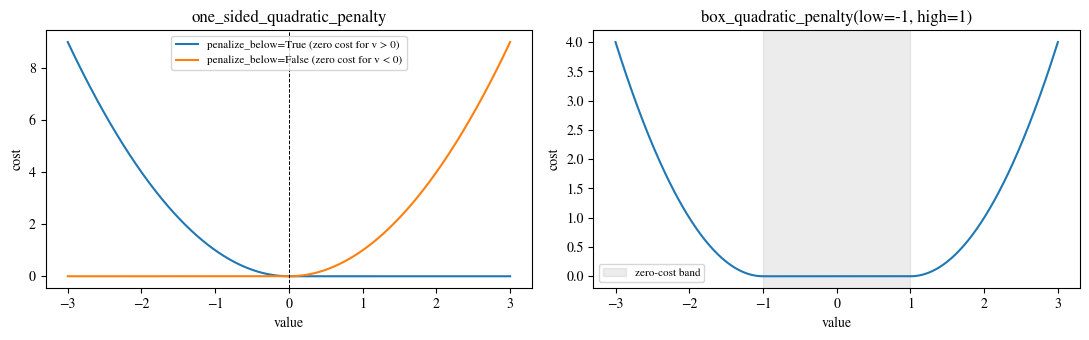

In [8]:
v = torch.linspace(-3, 3, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(v, one_sided_quadratic_penalty(v, threshold=0.0, penalize_below=True),
             label="penalize_below=True (zero cost for v > 0)")
axes[0].plot(v, one_sided_quadratic_penalty(v, threshold=0.0, penalize_below=False),
             label="penalize_below=False (zero cost for v < 0)")
axes[0].axvline(0, color="black", lw=0.7, ls="--")
axes[0].set_title("one_sided_quadratic_penalty")
axes[0].set_xlabel("value"); axes[0].set_ylabel("cost"); axes[0].legend(fontsize=8)

axes[1].plot(v, box_quadratic_penalty(v, low=-1.0, high=1.0))
axes[1].axvspan(-1, 1, color="gray", alpha=0.15, label="zero-cost band")
axes[1].set_title("box_quadratic_penalty(low=-1, high=1)")
axes[1].set_xlabel("value"); axes[1].set_ylabel("cost"); axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

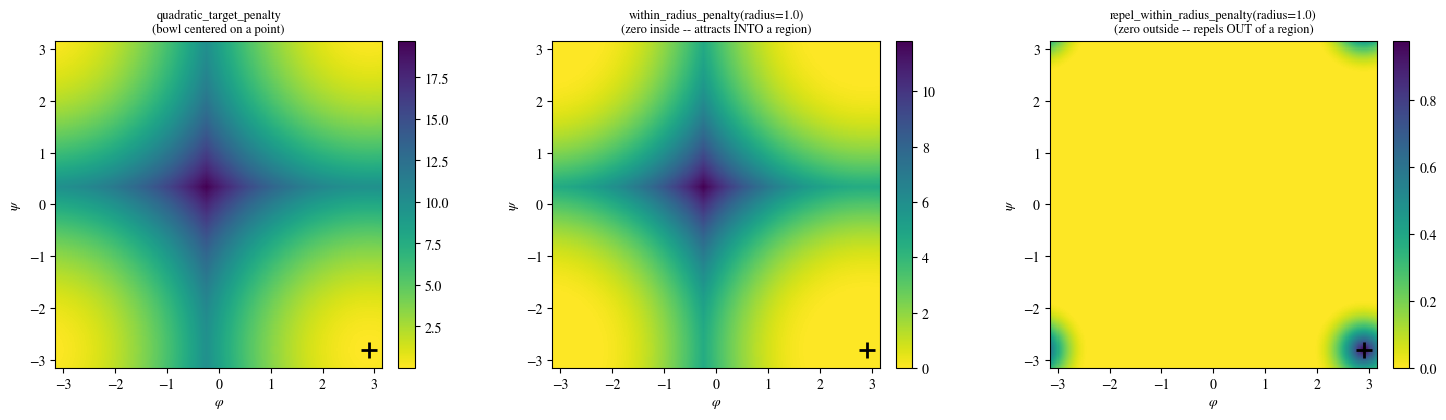

In [9]:
# torus_distance wraps at +-pi, so a center near the wrap still gives a smooth bowl/ring
phi_g = torch.linspace(-np.pi, np.pi, 300)
psi_g = torch.linspace(-np.pi, np.pi, 300)
PHI, PSI = torch.meshgrid(phi_g, psi_g, indexing="xy")

center = (2.9, -2.8)
dist = torus_distance(PHI, PSI, *center)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [
    ("quadratic_target_penalty\n(bowl centered on a point)", quadratic_target_penalty(dist)),
    ("within_radius_penalty(radius=1.0)\n(zero inside -- attracts INTO a region)", within_radius_penalty(dist, 1.0)),
    ("repel_within_radius_penalty(radius=1.0)\n(zero outside -- repels OUT of a region)", repel_within_radius_penalty(dist, 1.0)),
]
for ax, (title, cost) in zip(axes, panels):
    im = ax.pcolormesh(PHI.numpy(), PSI.numpy(), cost.numpy(), cmap="viridis_r", shading="auto")
    ax.plot(*center, marker="+", color="black", markersize=12, markeredgewidth=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(r"$\varphi$"); ax.set_ylabel(r"$\psi$")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 3. From atom positions to a differentiable cost

`guidance/observables.py` computes phi/psi dihedral angles directly from atom
positions, batched and autograd-friendly. Atom indices for a dihedral only
depend on the topology and are looked up once via `get_dihedral_atom_indices`
(`phi_idx`/`psi_idx` above).

The EGNN backbone is reflection-equivariant, so a raw sample `x1` can come
out as either the true molecule or its mirror image. Every cost function
below first corrects for that with `chirality_checker`, or guidance could
push the mirror sample toward the target instead of the real one.

In [10]:
# cost functions use the convention x1: (batch, atoms, 3) -> cost: (batch,)

PHI_TARGET_ANGLE = 1.0            # target for OBJECTIVE == "phi_target"
PHI_PSI_TARGET = (-2.0, 1.5)      # target for OBJECTIVE == "phi_psi_target"


def _chirality_fixed(x1: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        flip_mask = chirality_checker.flip_mask(x1)
    sign = torch.where(flip_mask, -1.0, 1.0).to(x1)[:, None, None]
    return x1 * sign


def pos_phi_cost_fn(x1: torch.Tensor) -> torch.Tensor:
    """One-sided penalty: zero cost once phi > 0."""
    phi = dihedrals(_chirality_fixed(x1), phi_idx)  # (batch, num_phi)
    return one_sided_quadratic_penalty(phi, threshold=0.0, penalize_below=True).sum(dim=-1)


def phi_target_cost_fn(x1: torch.Tensor) -> torch.Tensor:
    """Quadratic penalty, zero only at phi == PHI_TARGET_ANGLE (1-D target)."""
    phi = dihedrals(_chirality_fixed(x1), phi_idx)
    return box_quadratic_penalty(phi, low=PHI_TARGET_ANGLE, high=PHI_TARGET_ANGLE).sum(dim=-1)


def phi_psi_target_cost_fn(x1: torch.Tensor) -> torch.Tensor:
    """Periodic quadratic penalty, zero only at a single (phi, psi) point."""
    x1_fixed = _chirality_fixed(x1)
    phi = dihedrals(x1_fixed, phi_idx).squeeze(-1)
    psi = dihedrals(x1_fixed, psi_idx).squeeze(-1)
    dist = torus_distance(phi, psi, *PHI_PSI_TARGET)
    return quadratic_target_penalty(dist)


print("defined: pos_phi_cost_fn, phi_target_cost_fn, phi_psi_target_cost_fn")

defined: pos_phi_cost_fn, phi_target_cost_fn, phi_psi_target_cost_fn


## 4. Composing a richer target: the smiley face

The `smiley` objective composes the same primitives: attract into a circle
(the face), repel out of several small circles (the eyes and a row of
circles tracing a mouth).

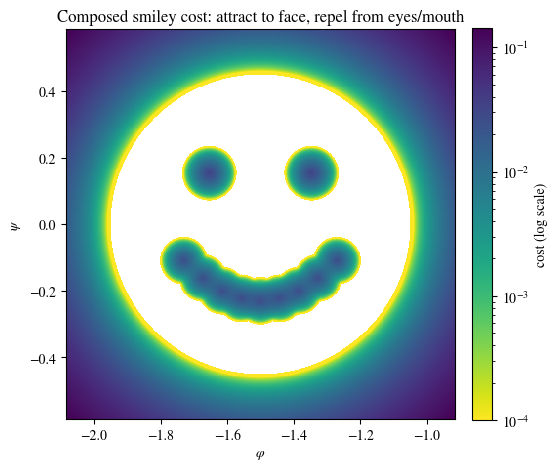

In [11]:
PHI_TARGET = (-2.0, -1.0)
PSI_TARGET = (-0.5, 0.5)

_BOX_CENTER = ((PHI_TARGET[0] + PHI_TARGET[1]) / 2, (PSI_TARGET[0] + PSI_TARGET[1]) / 2)
_BOX_HALF_EXTENT = min(PHI_TARGET[1] - PHI_TARGET[0], PSI_TARGET[1] - PSI_TARGET[0]) / 2
_SMILEY_SCALE = 0.9 * _BOX_HALF_EXTENT / 2.2
_INNER_SCALE = 0.75

FACE_CENTER = _BOX_CENTER
FACE_RADIUS = 2.2 * _SMILEY_SCALE

EYE_CENTERS = [
    (_BOX_CENTER[0] + dx * _INNER_SCALE * _SMILEY_SCALE, _BOX_CENTER[1] + dy * _INNER_SCALE * _SMILEY_SCALE)
    for dx, dy in [(-1.0, 1.0), (1.0, 1.0)]
]
EYE_RADIUS = 0.4 * _SMILEY_SCALE

MOUTH_PHIS = [-1.5, -1.125, -0.75, -0.375, 0.0, 0.375, 0.75, 1.125, 1.5]
MOUTH_CENTERS = [
    (
        _BOX_CENTER[0] + p * _INNER_SCALE * _SMILEY_SCALE,
        _BOX_CENTER[1] + (-1.5 + 0.35 * p**2) * _INNER_SCALE * _SMILEY_SCALE,
    )
    for p in MOUTH_PHIS
]
MOUTH_RADIUS = 0.35 * _SMILEY_SCALE

EYE_MOUTH_WEIGHT = 5.0


def _smiley_cost(phi: torch.Tensor, psi: torch.Tensor) -> torch.Tensor:
    dist_to_face = torus_distance(phi, psi, *FACE_CENTER)
    cost = within_radius_penalty(dist_to_face, FACE_RADIUS)
    for cx, cy in EYE_CENTERS:
        cost = cost + EYE_MOUTH_WEIGHT * repel_within_radius_penalty(torus_distance(phi, psi, cx, cy), EYE_RADIUS)
    for cx, cy in MOUTH_CENTERS:
        cost = cost + EYE_MOUTH_WEIGHT * repel_within_radius_penalty(torus_distance(phi, psi, cx, cy), MOUTH_RADIUS)
    return cost


def smiley_cost_fn(x1: torch.Tensor) -> torch.Tensor:
    x1_fixed = _chirality_fixed(x1)
    phi = dihedrals(x1_fixed, phi_idx).squeeze(-1)
    psi = dihedrals(x1_fixed, psi_idx).squeeze(-1)
    return _smiley_cost(phi, psi)


margin = 0.3 * FACE_RADIUS
phi_r = (FACE_CENTER[0] - FACE_RADIUS - margin, FACE_CENTER[0] + FACE_RADIUS + margin)
psi_r = (FACE_CENTER[1] - FACE_RADIUS - margin, FACE_CENTER[1] + FACE_RADIUS + margin)
gphi, gpsi = torch.linspace(*phi_r, 400), torch.linspace(*psi_r, 400)
GPHI, GPSI = torch.meshgrid(gphi, gpsi, indexing="xy")
C = _smiley_cost(GPHI, GPSI).numpy()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
im = ax.pcolormesh(GPHI.numpy(), GPSI.numpy(), C, cmap="viridis_r",
                    norm=LogNorm(vmin=1e-4, vmax=max(C.max(), 1e-3)), shading="auto")
ax.set_xlim(*phi_r); ax.set_ylim(*psi_r); ax.set_aspect("equal")
ax.set_xlabel(r"$\varphi$"); ax.set_ylabel(r"$\psi$")
ax.set_title("Composed smiley cost: attract to face, repel from eyes/mouth")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="cost (log scale)")
plt.show()

## 5. Guided Euler sampling

`guidance/euler_density_integrator.py` implements a guided fixed-step Euler
integrator. At each step it runs a few inner gradient-descent steps (default is 1) against
the *terminal* cost (the cost evaluated at the network's linear extrapolation
to `t=1`), teleports the state by that control shift, then takes the usual
Euler step. `gamma` controls how strongly the control shift is weighted, and
can ramp up over time via a callable of `t`.

`generate_proposal_guided_euler` wraps that into a drop-in proposal sampler.
Pick an `OBJECTIVE` below and run it. Adjust the GUIDANCE_LR to lower values for other objectives or if you aim for samples with lower energy.

In [12]:
import gc; gc.collect()
torch.cuda.empty_cache()

In [13]:
OBJECTIVE = "smiley"  # try "pos_phi", "phi_target", "phi_psi_target", or "smiley"

GUIDANCE_COST_FN = {
    "pos_phi": pos_phi_cost_fn,
    "phi_target": phi_target_cost_fn,
    "phi_psi_target": phi_psi_target_cost_fn,
    "smiley": smiley_cost_fn,
}[OBJECTIVE]

NUM_SAMPLES = 1000
EULER_STEPS = 250
GUIDANCE_INNER_STEPS = 1
GUIDANCE_LR = 2e-2          # alpha: inner gradient step length - 
# if you lower it, frac-in-target-bin goes down but mean-energy down up too
GUIDANCE_W_TERMINAL = 1.0   # weight on the terminal cost

# weight on the cost function for the "augmented" energy reported below
# (target_energy + AUGMENTED_ENERGY_COST_SCALE * cost) -- unrelated to
# GUIDANCE_W_TERMINAL, which weights the cost inside the sampler's own
# control objective. Large enough that samples far from the zero-cost
# region get near-zero probability under the implied exp(-augmented_energy)
# tilted distribution.
AUGMENTED_ENERGY_COST_SCALE = 20.0

# gamma schedule: ramp 0 -> GAMMA_HI over the first steps, then hold
GAMMA_HI = 2.0
GAMMA_LO_SLOPE = 12.0
GAMMA_THRESHOLD = 0.0


def gamma_fn(t: torch.Tensor) -> float:
    if t <= GAMMA_THRESHOLD:
        return GAMMA_LO_SLOPE * t
    return GAMMA_HI


def single_sample_cost_fn(x1_flat: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    return GUIDANCE_COST_FN(x1_flat.view(1, -1, 3)).squeeze()


torch.manual_seed(42)
x, neg_logq, valid = sample_guided_batched(
    NUM_SAMPLES, BATCH_SIZE_NO_DENSITY,
    lambda x1, t: GUIDANCE_W_TERMINAL * single_sample_cost_fn(x1, t),
    gamma=gamma_fn, alpha=GUIDANCE_LR, lam=0.0, beta=0.0,
    n_inner=GUIDANCE_INNER_STEPS, n_steps=EULER_STEPS,
    device=device, track_density=False,
)
samples = x.cpu()  # normalized space
print(f"sampled {samples.shape[0]} guided conformations toward OBJECTIVE={OBJECTIVE!r}")

sampling batches: 100%|██████████| 8/8 [07:32<00:00, 56.59s/it]

sampled 1000 guided conformations toward OBJECTIVE='smiley'


chirality: flipped 49.6% of samples to match the true reference


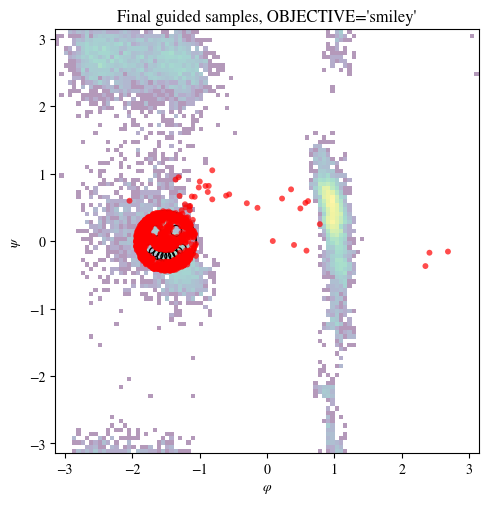

In [14]:
samples_physical = destandardize_coords(samples, eval_ctx.normalization_std)
flip_mask = chirality_checker.flip_mask(samples_physical)
samples_physical = samples_physical.clone()
samples_physical[flip_mask] *= -1
print(f"chirality: flipped {flip_mask.float().mean():.1%} of samples to match the true reference")

phi_final = dihedrals(samples_physical, phi_idx).squeeze(-1).numpy()
psi_final = dihedrals(samples_physical, psi_idx).squeeze(-1).numpy()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.hist2d(phi_unguided, psi_unguided, 100, norm=LogNorm(), range=[[-np.pi, np.pi], [-np.pi, np.pi]],
          alpha=0.4, zorder=1)
ax.scatter(phi_final, psi_final, s=18, c="red", alpha=0.7, edgecolors="none", zorder=5)

if OBJECTIVE == "smiley":
    ax.add_patch(Circle(FACE_CENTER, FACE_RADIUS, fill=False, edgecolor="black", linewidth=1.2, zorder=3))
    for cx, cy in EYE_CENTERS:
        ax.add_patch(Circle((cx, cy), EYE_RADIUS, fill=False, edgecolor="black", linewidth=1.0, zorder=3))
    for cx, cy in MOUTH_CENTERS:
        ax.add_patch(Circle((cx, cy), MOUTH_RADIUS, fill=False, edgecolor="black", linewidth=1.0, zorder=3))
elif OBJECTIVE == "phi_psi_target":
    ax.plot(*PHI_PSI_TARGET, marker="+", markersize=16, markeredgewidth=2, color="black", zorder=3)
elif OBJECTIVE == "phi_target":
    ax.axvline(PHI_TARGET_ANGLE, color="black", linestyle="--", linewidth=0.8, zorder=3)
elif OBJECTIVE == "pos_phi":
    ax.axvline(0.0, color="black", linestyle="--", linewidth=0.8, zorder=3)

ax.set_xlim(-np.pi, np.pi); ax.set_ylim(-np.pi, np.pi); ax.set_aspect("equal")
ax.set_xlabel(r"$\varphi$"); ax.set_ylabel(r"$\psi$")
ax.set_title(f"Final guided samples, OBJECTIVE={OBJECTIVE!r}")
plt.show()

For per-residue free-energy-scaled Ramachandran histograms saved to disk, use
`plot_ramachandran` directly:

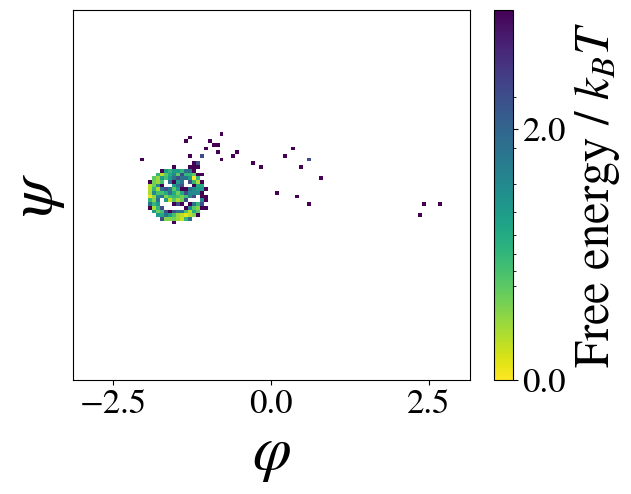

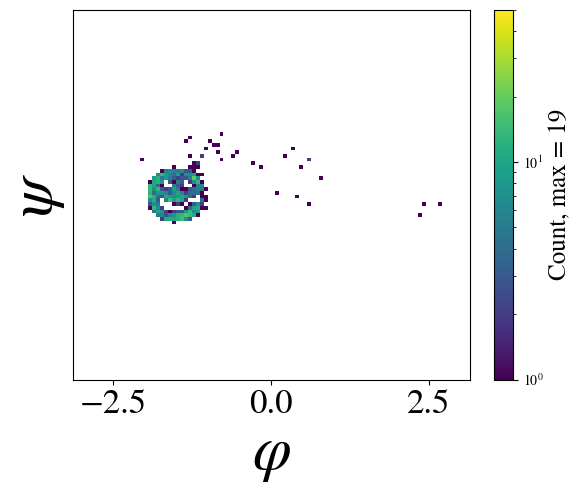

In [15]:
plot_ramachandran(
    log_image_fn, samples_physical, eval_ctx.topology,
    prefix=f"notebook_guided_{OBJECTIVE}",
    phi_target=PHI_TARGET_ANGLE if OBJECTIVE == "phi_target" else None,
)

For `OBJECTIVE == "smiley"`, the fraction of guided samples inside the face
circle (attracted region) and inside any eye/mouth exclusion circle
(repelled region) is reported. Also compares mean target energy against a
rejection-sampling baseline: the unguided samples from section 1 that
already land in the zero-cost region on their own, without any guidance
steering them there.

For better sampling quality regarding the energy you have to lower the GUIDANCE_LR down to 4e-3. This comes ate the same time with lower fraction in the target.

In [16]:
phi_generated = dihedrals(samples_physical, phi_idx).squeeze(-1)
psi_generated = dihedrals(samples_physical, psi_idx).squeeze(-1)

with torch.no_grad():
    e_generated = eval_ctx.target_energy.energy(samples)
    cost_unguided = GUIDANCE_COST_FN(samples_unguided_physical)
    cost_guided = GUIDANCE_COST_FN(samples_physical)
    cost_true = GUIDANCE_COST_FN(eval_ctx.true_data.samples)

# rejection-sampling baseline: unguided samples that already fall in the
# zero-cost region on their own, instead of all unguided samples
zero_cost_mask = cost_unguided <= 1e-8
zero_cost_mask_gen = cost_guided <= 1e-8
num_rejected = int(zero_cost_mask.sum().item())
print(f"{num_rejected}/{NUM_SAMPLES_UNGUIDED} unguided samples fall in the zero-cost region (OBJECTIVE={OBJECTIVE!r})")

metrics = {
    "mean-energy-in-smiley": e_generated[zero_cost_mask_gen].mean().item(),
}

if OBJECTIVE == "smiley":
    dist_to_face = torus_distance(phi_generated, psi_generated, *FACE_CENTER)
    in_face_circle = dist_to_face <= FACE_RADIUS

    in_eye_or_mouth = torch.zeros_like(in_face_circle)
    for cx, cy in EYE_CENTERS:
        dist = torus_distance(phi_generated, psi_generated, cx, cy)
        in_eye_or_mouth = in_eye_or_mouth | (dist <= EYE_RADIUS)
    for cx, cy in MOUTH_CENTERS:
        dist = torus_distance(phi_generated, psi_generated, cx, cy)
        in_eye_or_mouth = in_eye_or_mouth | (dist <= MOUTH_RADIUS)

    metrics["frac-in-face-circle"] = in_face_circle.float().mean().item()
    metrics["frac-in-eye-or-mouth"] = in_eye_or_mouth.float().mean().item()

if num_rejected > 0:
    with torch.no_grad():
        e_rejected = eval_ctx.target_energy.energy(samples_unguided[zero_cost_mask])
    metrics["mean-energy-rejected-unguided"] = e_rejected.mean().item()
    metrics.update(energy_wasserstein(pred_energy=e_generated, true_energy=e_rejected, prefix="guided-vs-rejected-unguided"))
else:
    print("no unguided samples landed in the zero-cost region -- raise NUM_SAMPLES in section 1 to compare")

print("\n".join(f"{k}: {v:.4f}" for k, v in metrics.items()))

816/10000 unguided samples fall in the zero-cost region (OBJECTIVE='smiley')
mean-energy-in-smiley: -1.1813
frac-in-face-circle: 0.9590
frac-in-eye-or-mouth: 0.0010
mean-energy-rejected-unguided: -26.7067
guided-vs-rejected-unguided/energy-w2: 182.9083
guided-vs-rejected-unguided/energy-w1: 42.1309


In [17]:
import gc; gc.collect()
torch.cuda.empty_cache()

## 6. Animating a guided trajectory as a GIF

`gif_guided_trajectory.py` exposes `make_guided_trajectory_gif`, which
integrates guided Euler steps, records phi/psi per frame, and saves an
animated GIF. It takes the cost function and guidance hyperparameters as
plain arguments, so it's reused here directly instead of reimplementing the
loop. `background_density` renders the unguided distribution from section 1
behind the guided trajectory, for the same comparison as the plot above.

In [18]:
def draw_targets(ax: plt.Axes) -> None:
    if OBJECTIVE == "smiley":
        ax.add_patch(Circle(FACE_CENTER, FACE_RADIUS, fill=False, edgecolor="black", linewidth=1.2, zorder=3))
        for cx, cy in EYE_CENTERS:
            ax.add_patch(Circle((cx, cy), EYE_RADIUS, fill=False, edgecolor="black", linewidth=1.0, zorder=3))
        for cx, cy in MOUTH_CENTERS:
            ax.add_patch(Circle((cx, cy), MOUTH_RADIUS, fill=False, edgecolor="black", linewidth=1.0, zorder=3))
    elif OBJECTIVE == "phi_psi_target":
        ax.plot(*PHI_PSI_TARGET, marker="+", markersize=16, markeredgewidth=2, color="black", zorder=3)
    elif OBJECTIVE == "phi_target":
        ax.axvline(PHI_TARGET_ANGLE, color="black", linestyle="--", linewidth=0.8, zorder=3)
    elif OBJECTIVE == "pos_phi":
        ax.axvline(0.0, color="black", linestyle="--", linewidth=0.8, zorder=3)


GIF_PATH = make_guided_trajectory_gif(
    model, num_atoms, phi_idx, psi_idx, chirality_checker,
    cost_fn=lambda x1, t: GUIDANCE_W_TERMINAL * GUIDANCE_COST_FN(x1),
    gif_path=OUT_DIR / f"notebook_guided_trajectory_{OBJECTIVE}.gif",
    num_samples=NUM_GIF_SAMPLES,
    euler_steps=EULER_STEPS,
    num_frames=NUM_FRAMES,
    gamma=gamma_fn,
    alpha=GUIDANCE_LR,
    n_inner=GUIDANCE_INNER_STEPS,
    seed=0,
    background_density=(phi_unguided, psi_unguided),
    device=device,
    draw_targets=draw_targets,
)
print(f"saved {GIF_PATH}")

saved /workspace/guided_BG/tests/guidance/out/notebook_guided_trajectory_smiley.gif


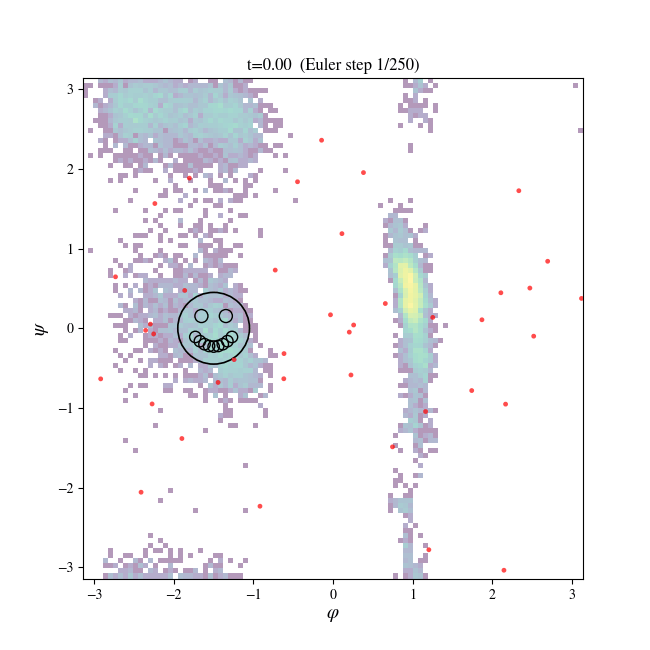

In [19]:
from IPython.display import Image

Image(filename=str(GIF_PATH))

In [20]:
import gc; gc.collect()
torch.cuda.empty_cache()

## 7. Guided sampling with exact density tracking

Exact log-density (`track_density=True`) computes a full Jacobian at every
step and checks that it stays orientation-preserving (see
`guided_euler_exact`). Because of resulting Hessians, this is far more expensive than the plain guided sampling
above, so it's only run on a small batch here. This is also why `GUIDANCE_INNER_STEPS` should not be larger 1.

Reports wall-clock runtime
and which samples (if any) had an orientation flip. Compare the runtime to those in the integrator_comparison_tutorial.

In [21]:
NUM_SAMPLES_DENSITY = 8

# Per-sample list of Euler step indices where that step's Jacobian determinant
# was non-positive (orientation flip). Keyed by global sample index, so it
# stays correct across sample_guided_batched's internal batching.
flip_steps_by_sample: dict[int, list[int]] = {}
_batch_state = {"offset": 0, "last_k": None, "last_batch_size": 0}


def _record_flip_steps(k: int, step_valid: torch.Tensor) -> None:
    if _batch_state["last_k"] is None or k <= _batch_state["last_k"]:
        _batch_state["offset"] += _batch_state["last_batch_size"]  # new batch started
    _batch_state["last_k"] = k
    _batch_state["last_batch_size"] = step_valid.shape[0]
    for local_idx in torch.nonzero(~step_valid).squeeze(-1).tolist():
        flip_steps_by_sample.setdefault(_batch_state["offset"] + local_idx, []).append(k)


torch.manual_seed(42)
t0 = time.time()
x_density, neg_logq_density, valid_density = sample_guided_batched(
    NUM_SAMPLES_DENSITY, BATCH_SIZE_DENSITY,
    lambda x1, t: GUIDANCE_W_TERMINAL * single_sample_cost_fn(x1, t),
    gamma=gamma_fn, alpha=GUIDANCE_LR, lam=0.0, beta=0.0,
    n_inner=GUIDANCE_INNER_STEPS, n_steps=EULER_STEPS,
    device=device, track_density=True, raise_on_orientation_failure=False,
    on_step=_record_flip_steps,
)
if device == "cuda":
    torch.cuda.synchronize()
runtime = time.time() - t0

print(f"generated {NUM_SAMPLES_DENSITY} guided samples with exact density tracking "
      f"in {runtime:.1f}s (OBJECTIVE={OBJECTIVE!r}, n_steps={EULER_STEPS})")

num_flipped = int((~valid_density).sum().item())
if num_flipped == 0:
    print("no orientation flips occurred")
else:
    flipped_idx = torch.nonzero(~valid_density).squeeze(-1).tolist()
    print(f"orientation flip occurred in {num_flipped}/{NUM_SAMPLES_DENSITY} samples (indices: {flipped_idx})")
    for idx in flipped_idx:
        steps = flip_steps_by_sample.get(idx, [])
        print(f"  sample {idx}: flipped at Euler step(s) {steps} (of {EULER_STEPS}); first flip at step {steps[0]}")

sampling batches: 100%|██████████| 1/1 [07:51<00:00, 471.69s/it]

generated 8 guided samples with exact density tracking in 471.7s (OBJECTIVE='smiley', n_steps=250)
orientation flip occurred in 3/8 samples (indices: [0, 1, 7])
  sample 0: flipped at Euler step(s) [33, 34, 58] (of 250); first flip at step 33
  sample 1: flipped at Euler step(s) [192] (of 250); first flip at step 192
  sample 7: flipped at Euler step(s) [203, 204, 205, 206, 207] (of 250); first flip at step 203


## Next steps

- Change `OBJECTIVE` in section 5 (and re-run sections 5-7) to try
  `pos_phi`, `phi_target`, or `phi_psi_target`.
- Lower `GUIDANCE_LR` to obtain lower energy samples.
- Try to avoid orientation flips in the exact density sampling 